数据形状: (5855, 66)
目标变量分布:
 ms_cds
0    5320
1     535
Name: count, dtype: int64

=== BestSHINEMS ===
平均准确率: 0.8360
平均精确率: 0.2848
平均召回率: 0.5178
平均F1-Score: 0.3669
平均AUC值: 0.8095

=== Extra Trees ===
平均准确率: 0.8253
平均精确率: 0.2681
平均召回率: 0.5252
平均F1-Score: 0.3548
平均AUC值: 0.7944

=== Decision Tree ===
平均准确率: 0.7402
平均精确率: 0.1767
平均召回率: 0.5028
平均F1-Score: 0.2615
平均AUC值: 0.6335

=== Hist Gradient Boosting ===
平均准确率: 0.8159
平均精确率: 0.2648
平均召回率: 0.5664
平均F1-Score: 0.3607
平均AUC值: 0.8024

正在计算 BestSHINEMS 的学习曲线（AUC），可能需要一点时间...

正在计算 Extra Trees 的学习曲线（AUC），可能需要一点时间...

正在计算 Decision Tree 的学习曲线（AUC），可能需要一点时间...

正在计算 Hist Gradient Boosting 的学习曲线（AUC），可能需要一点时间...


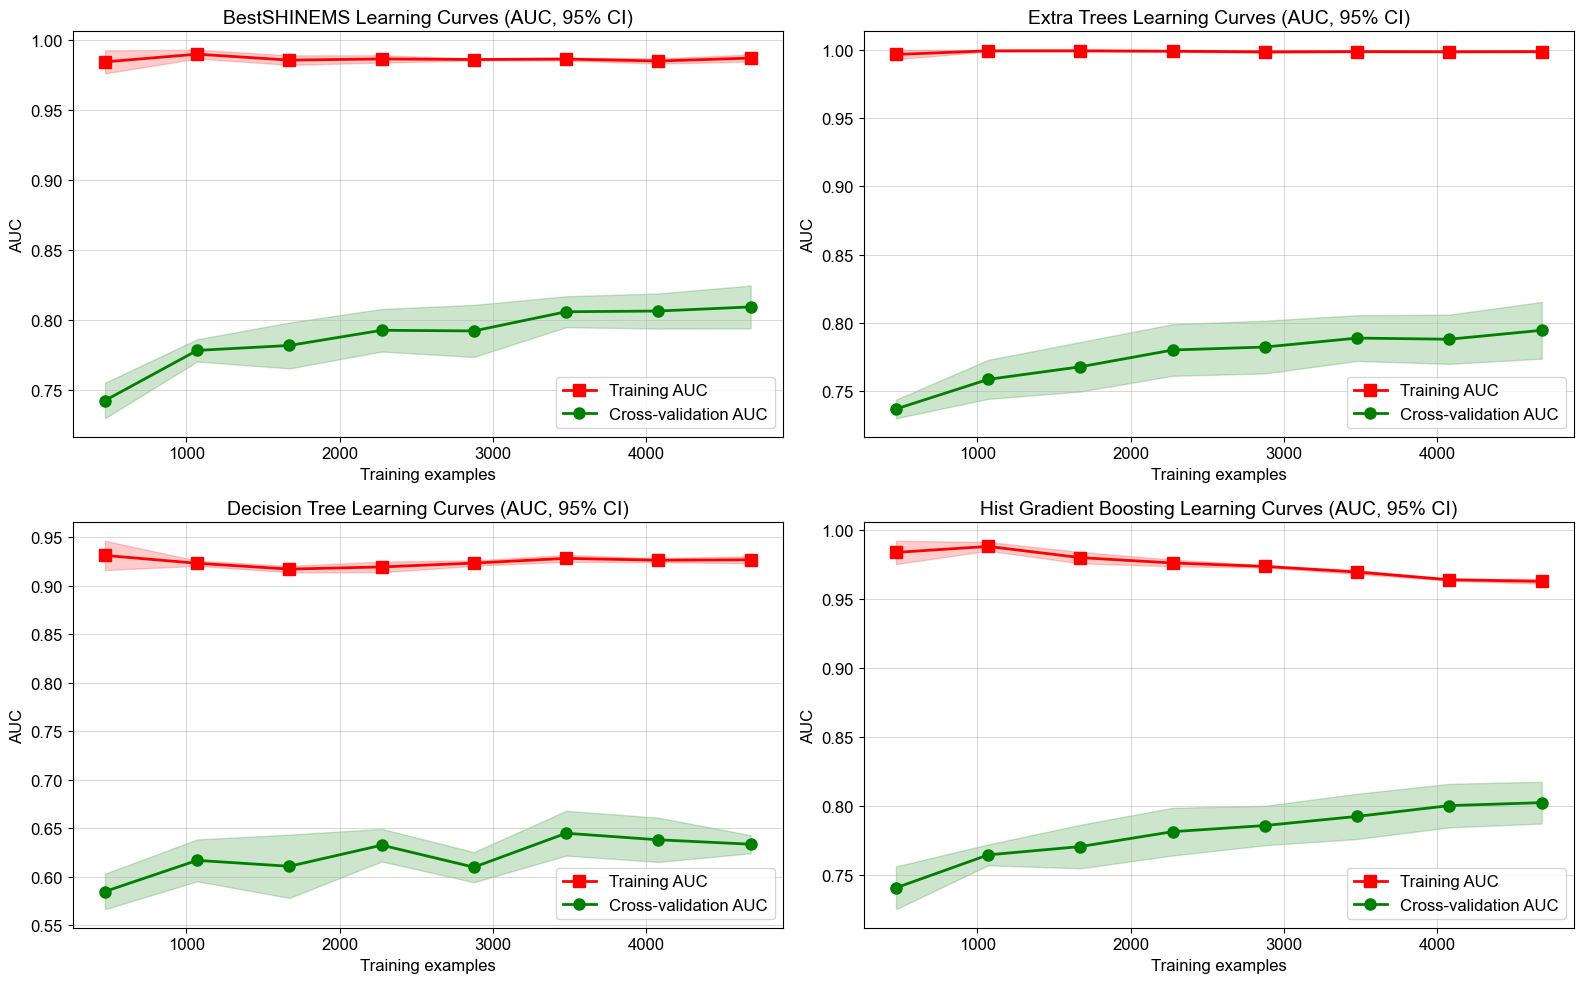


学习曲线（AUC）已保存为 learning_curves_auc.png


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_validate, StratifiedKFold, learning_curve

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek, SMOTEENN

import xgboost as xgb
from sklearn.ensemble import (ExtraTreesClassifier, HistGradientBoostingClassifier)
from sklearn.tree import DecisionTreeClassifier

df1 = pd.read_csv('../数据/训练集.csv')
df2 = pd.read_csv('../数据/测试集.csv')
df = pd.concat([df1, df2], ignore_index=True)
print("数据形状:", df.shape)
print("目标变量分布:\n", df['ms_cds'].value_counts())
tezheng = ['ggt', 'drinking', 'ast', 'age', 'hr', 'alt', 'mono', 'gender', 'umalb', 'sua', 'dbil', 'bun', 'tp', 'idbil', 'rbc']
X = df[tezheng]
y = df['ms_cds']
paras =  {'n_estimators': 514, 'learning_rate': 0.11483790, 'max_depth': 14, 'min_child_weight': 1, 'subsample': 0.86841410, 'colsample_bytree': 0.41070400, 'reg_alpha': 0.12015366, 'reg_lambda': 0.00028341, 'gamma': 3.45672074e-06}
models = {
    "BestSHINEMS": ImbPipeline([
        ('sampler', SMOTEENN(random_state=42, n_jobs=-1)),
        ('classifier', xgb.XGBClassifier(**paras,n_jobs=-1, random_state=42, eval_metric='logloss', use_label_encoder=False))
    ]),
    "Extra Trees": ImbPipeline([
        ('sampler', SMOTEENN(random_state=42, n_jobs=-1)),
        ('classifier', ExtraTreesClassifier(n_jobs=-1, random_state=42))
    ]),
    "Decision Tree": ImbPipeline([
        ('sampler', SMOTEENN(random_state=42, n_jobs=-1)),
        ('classifier', DecisionTreeClassifier(random_state=42))
    ]),
    "Hist Gradient Boosting": ImbPipeline([
        ('sampler', SMOTEENN(random_state=42, n_jobs=-1)),
        ('classifier', HistGradientBoostingClassifier(random_state=42))
    ])
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
n_folds = cv.get_n_splits()
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results = []
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    avg_accuracy = scores['test_accuracy'].mean()
    avg_precision = scores['test_precision'].mean()
    avg_recall = scores['test_recall'].mean()
    avg_f1 = scores['test_f1'].mean()
    avg_auc = scores['test_roc_auc'].mean()

    results.append({
        'Model': name,
        'Accuracy': avg_accuracy,
        'Precision': avg_precision,
        'Recall': avg_recall,
        'F1-Score': avg_f1,
        'AUC': avg_auc
    })

    print(f"\n=== {name} ===")
    print(f"平均准确率: {avg_accuracy:.4f}")
    print(f"平均精确率: {avg_precision:.4f}")
    print(f"平均召回率: {avg_recall:.4f}")
    print(f"平均F1-Score: {avg_f1:.4f}")
    print(f"平均AUC值: {avg_auc:.4f}")

# 定义训练集大小（相对比例，取8个点）
train_sizes = np.linspace(0.1, 1.0, 8)   # 从10%到100%的训练数据

# 全局绘图样式（和验证曲线完全统一）
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.linestyle'] = '-'
plt.rcParams['grid.alpha'] = 0.7

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

# 对每个模型单独计算学习曲线并绘制
for idx, (name, model) in enumerate(models.items()):
    print(f"\n正在计算 {name} 的学习曲线（AUC），可能需要一点时间...")
    # 计算学习曲线，评估指标使用 roc_auc
    train_sizes_abs, train_scores, test_scores = learning_curve(
        model, X, y,
        cv=cv,                      # 使用相同的5折分层交叉验证
        scoring='roc_auc',
        train_sizes=train_sizes,
        n_jobs=-1,
        random_state=42
    )

    # 计算均值和标准差
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    # 标准误 = 标准差 / sqrt(折数)
    train_se = train_std / np.sqrt(n_folds)
    test_se = test_std / np.sqrt(n_folds)
    ci_factor = 1.96   # 对应95%置信区间（正态分布假设）

    # 绘制学习曲线，阴影为 均值 ± 1.96 * 标准误
    ax = axes[idx]
    ax.fill_between(train_sizes_abs,
                    train_mean - ci_factor * train_se,
                    train_mean + ci_factor * train_se,
                    alpha=0.2, color='red')
    ax.plot(train_sizes_abs, train_mean, 'r-s', linewidth=2, markersize=8, label="Training AUC")


    ax.fill_between(train_sizes_abs,
                    test_mean - ci_factor * test_se,
                    test_mean + ci_factor * test_se,
                    alpha=0.2, color='green')
    ax.plot(train_sizes_abs, test_mean, 'g-o', linewidth=2, markersize=8, label="Cross-validation AUC")

    ax.set_title(f"{name} Learning Curves (AUC, 95% CI)", fontsize=14)
    ax.set_xlabel("Training examples", fontsize=12)
    ax.set_ylabel("AUC", fontsize=12)
    ax.legend(fontsize=12)
    ax.grid(True, linestyle='-', alpha=0.7)

plt.tight_layout()
plt.savefig('学习曲线.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n学习曲线（AUC）已保存为 learning_curves_auc.png")